## State of the Coast

### Packages

In [1]:
# Packages
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from deltaeo.modules import shorelines
from dotenv import load_dotenv
from resplotlib import rpc

from state_of_the_delta import Memo

# Load environment variables
load_dotenv()

c:\Users\white_rn\Documents\GitHub\state-of-the-delta\.venv\Lib\site-packages\langgraph\checkpoint\base\__init__.py:17: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

### Settings

In [2]:
# Directories
repo_path = Path.cwd().parents[0]
dir_path_templates = repo_path / "data" / "00_templates"
dir_path_areas = repo_path / "data" / "01_areas"
dir_path_figures = repo_path / "data" / "02_figures"
dir_path_memos = repo_path / "data" / "03_memos"

# Area of interest
area_name = "terschelling"

# Template
template_name = "state_of_the_coast"

In [3]:
# Read geometries
gdf_areas = gpd.read_file(dir_path_areas / f"{area_name}.geojson")

# Get transects and series
gdf_all_transects = shorelines.get_assets_from_stac(gdf=gdf_areas, collection="transects").to_crs(gdf_areas.crs)
gdf_all_series = shorelines.get_assets_from_stac(gdf=gdf_areas, collection="series").to_crs(gdf_areas.crs)

# Get coastal types
gdf_points = gdf_all_transects[["sds:change_rate", "class:coastal_type", "geometry"]].rename(
    columns={"sds:change_rate": "change_rate", "class:coastal_type": "coastal_type"}
)
gdf_points["geometry"] = gdf_points["geometry"].apply(lambda x: x.interpolate(0.5, normalized=True))


# Sample 3 transects that have extreme change rates
n_transects = 3
gdf_transects = gdf_all_transects[gdf_all_transects["sds:change_rate"].abs() > 5].sample(n=n_transects).reset_index(drop=True)
gdf_transects["id"] = gdf_transects.index + 1

# Get series for the sampled transects
gdf_series = gdf_all_series[gdf_all_series["transect_id"].isin(gdf_transects["transect_id"])]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### Figures

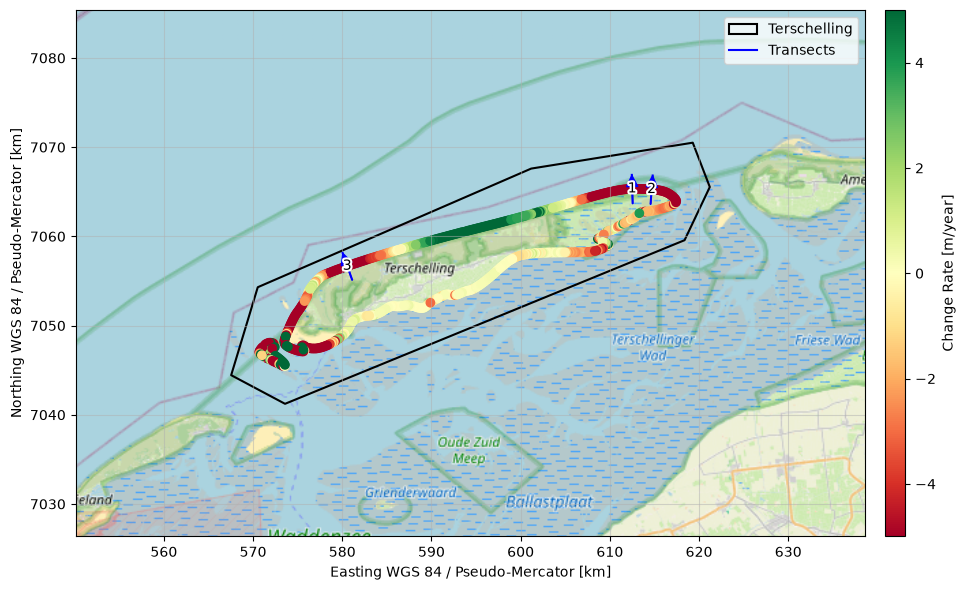

In [4]:
# Plot settings
bounds = gdf_areas.total_bounds
center = [(bounds[0] + bounds[2]) / 2, (bounds[1] + bounds[3]) / 2]

height = max(bounds[2] - bounds[0], bounds[3] - bounds[1]) * 1.1
width = height * 1.5
xlim = [center[0] - width / 2, center[0] + width / 2]
ylim = [center[1] - height / 2, center[1] + height / 2]

# Plot map
fig, ax = rpc.subplots(1, figsize=(16, 6))
rpc.geometries(gdf_areas, ax=ax, style="aoi", label=f"{area_name}".replace("_", " ").capitalize())
rpc.geometries(gdf_points, ax=ax, column="change_rate", cmap="RdYlGn", vmin=-5, vmax=5, legend=True, legend_kwds={"label": "Change Rate [m/year]"})
rpc.geometries(gdf_transects, label_column="id", ax=ax, color="blue", add_arrow=True, label="Transects")
rpc.basemap(crs=gdf_areas.crs, ax=ax, style="osm", attribution=False, xlim=xlim, ylim=ylim)
ax.legend()
rpc.save(fig, file_path=dir_path_figures / f"{template_name}_{area_name}_map.png".lower().replace(" ", "_"))
rpc.show(fig)

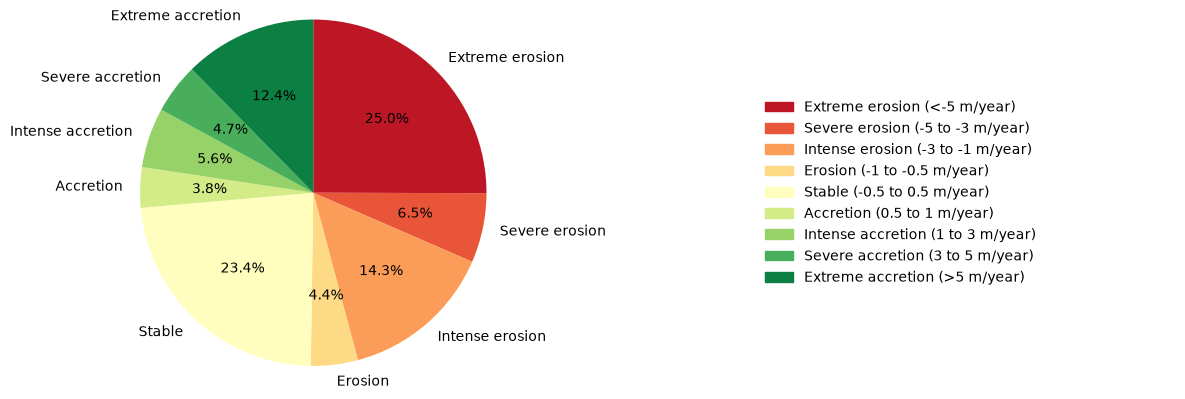

In [5]:
# Plot settings
labels = [
    "Extreme erosion (<-5 m/year)",
    "Severe erosion (-5 to -3 m/year)",
    "Intense erosion (-3 to -1 m/year)",
    "Erosion (-1 to -0.5 m/year)",
    "Stable (-0.5 to 0.5 m/year)",
    "Accretion (0.5 to 1 m/year)",
    "Intense accretion (1 to 3 m/year)",
    "Severe accretion (3 to 5 m/year)",
    "Extreme accretion (>5 m/year)",
]
colors = [mpl.cm.RdYlGn(i) for i in np.linspace(0.05, 0.95, len(labels))]
bins = [-np.inf, -5, -3, -1, -0.5, 0.5, 1, 3, 5, np.inf]
sizes = np.histogram(gdf_points["change_rate"].values, bins=bins)[0]
percentages = sizes / sizes.sum() * 100

# Plot pie chart
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].pie(
    percentages,
    labels=[label.split(" (")[0].replace("\n", " ") for label in labels],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
)
axs[0].axis("equal")
axs[1].legend(
    handles=[mpl.patches.Patch(color=colors[i], label=labels[i]) for i in range(len(labels))],
    loc="center",
    frameon=False,
)
axs[1].axis("off")
rpc.save(fig, file_path=dir_path_figures / f"{template_name}_{area_name}_chart.png".lower().replace(" ", "_"))
rpc.show(fig)

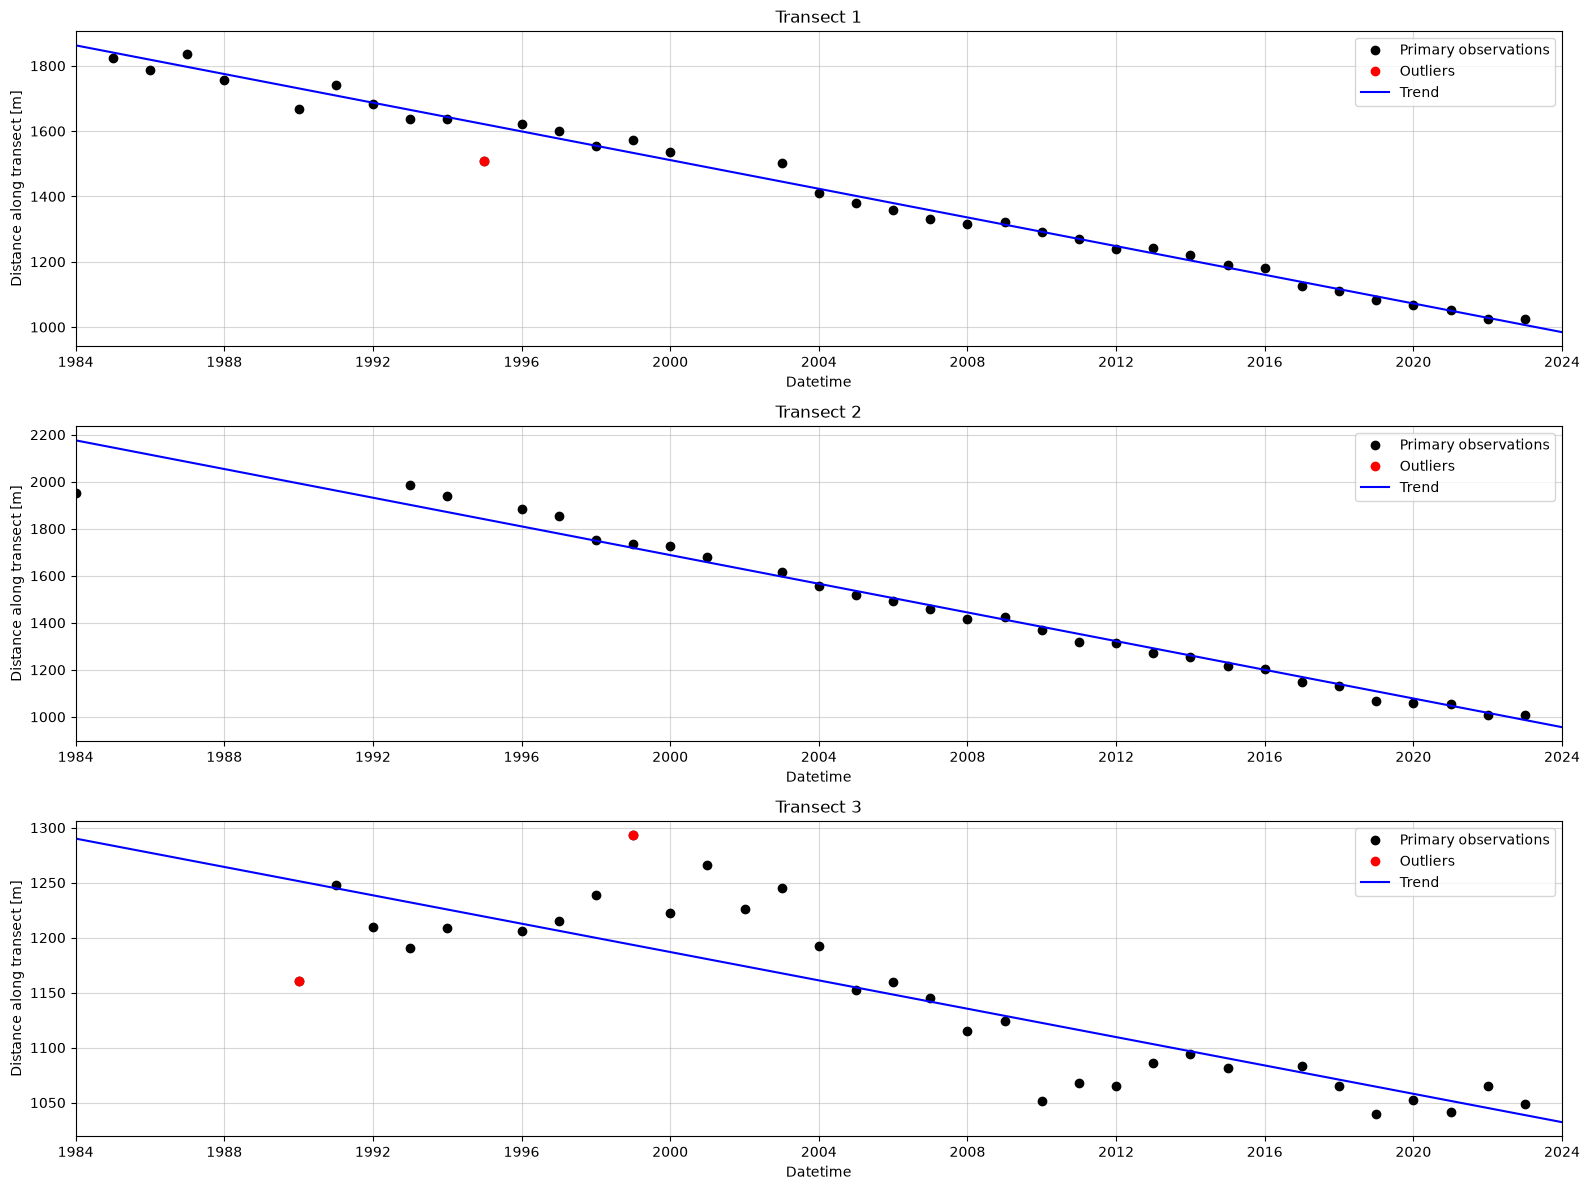

In [6]:
def plot_series(gdf_series, gdf_transect, ax):
    # Get the transect ID
    transect_id = gdf_transect["transect_id"].iloc[0]
    gdf_transect_series = gdf_series[gdf_series["transect_id"] == transect_id]

    gdf_primary = gdf_transect_series[gdf_transect_series["obs_is_primary"]]
    gdf_outlier = gdf_transect_series[gdf_transect_series["obs_is_outlier"]]

    ax.plot(gdf_primary["datetime"].values, gdf_primary["chainage"].values, marker="o", linestyle="none", color="black", label="Primary observations")
    ax.plot(gdf_outlier["datetime"].values, gdf_outlier["chainage"].values, marker="o", linestyle="none", color="red", label="Outliers")

    dates = [pd.to_datetime("1984-01-01"), pd.to_datetime("2024-01-01")]
    date_zero = pd.to_datetime("0000-01-01")
    change_intercept = gdf_transect["sds:change_intercept"].iloc[0]
    change_rate = gdf_transect["sds:change_rate"].iloc[0]
    chainages = [change_intercept + change_rate * (date - date_zero).days / 365.25 for date in dates]
    ax.plot(dates, chainages, color="blue", label="Trend")

    ax.set_title(f"Transect {gdf_transect['id'].iloc[0]}")
    ax.set_xlabel("Datetime")

    ax.set_xlim(pd.to_datetime("1984-01-01"), pd.to_datetime("2024-01-01"))
    ax.set_ylabel("Distance along transect [m]")
    ax.grid(alpha=0.5)
    ax.legend(loc="upper right")


fig, ax = rpc.subplots(nrows=n_transects, figsize=(16, 4 * n_transects))
for i, row in gdf_transects.iterrows():
    gdf_transect = gdf_transects.iloc[[i]]
    plot_series(gdf_series=gdf_series, gdf_transect=gdf_transect, ax=ax[i])
rpc.save(fig=fig, file_path=dir_path_figures / f"{template_name}_{area_name}_transects.png".lower().replace(" ", "_"))
rpc.show(fig)


### Memo

INFO:httpx:HTTP Request: POST https://openaicoastal.openai.azure.com/openai/deployments/text-embedding-3-large/embeddings?api-version=2024-12-01-preview "HTTP/1.1 200 OK"
INFO:azure.core.pipeline.policies.http_logging_policy:Request URL: 'https://searchcoastal.search.windows.net/indexes('minikennisbank_state_of_the_coast')/docs/search.post.search?api-version=2026-04-01'
Request method: 'POST'
Request headers:
    'Content-Type': 'application/json'
    'Content-Length': '63654'
    'Accept': 'application/json;odata.metadata=none'
    'x-ms-client-request-id': '18a23121-aab7-11f1-8a6e-005056acadae'
    'User-Agent': 'azsdk-python-search-documents/12.0.0 Python/3.12.14 (Windows-11-10.0.26200-SP0)'
    'api-key': 'REDACTED'
A body is sent with the request
INFO:azure.core.pipeline.policies.http_logging_policy:Response status: 200
Response headers:
    'Transfer-Encoding': 'chunked'
    'Content-Type': 'application/json; odata.metadata=none; odata.streaming=true; charset=utf-8'
    'Content-


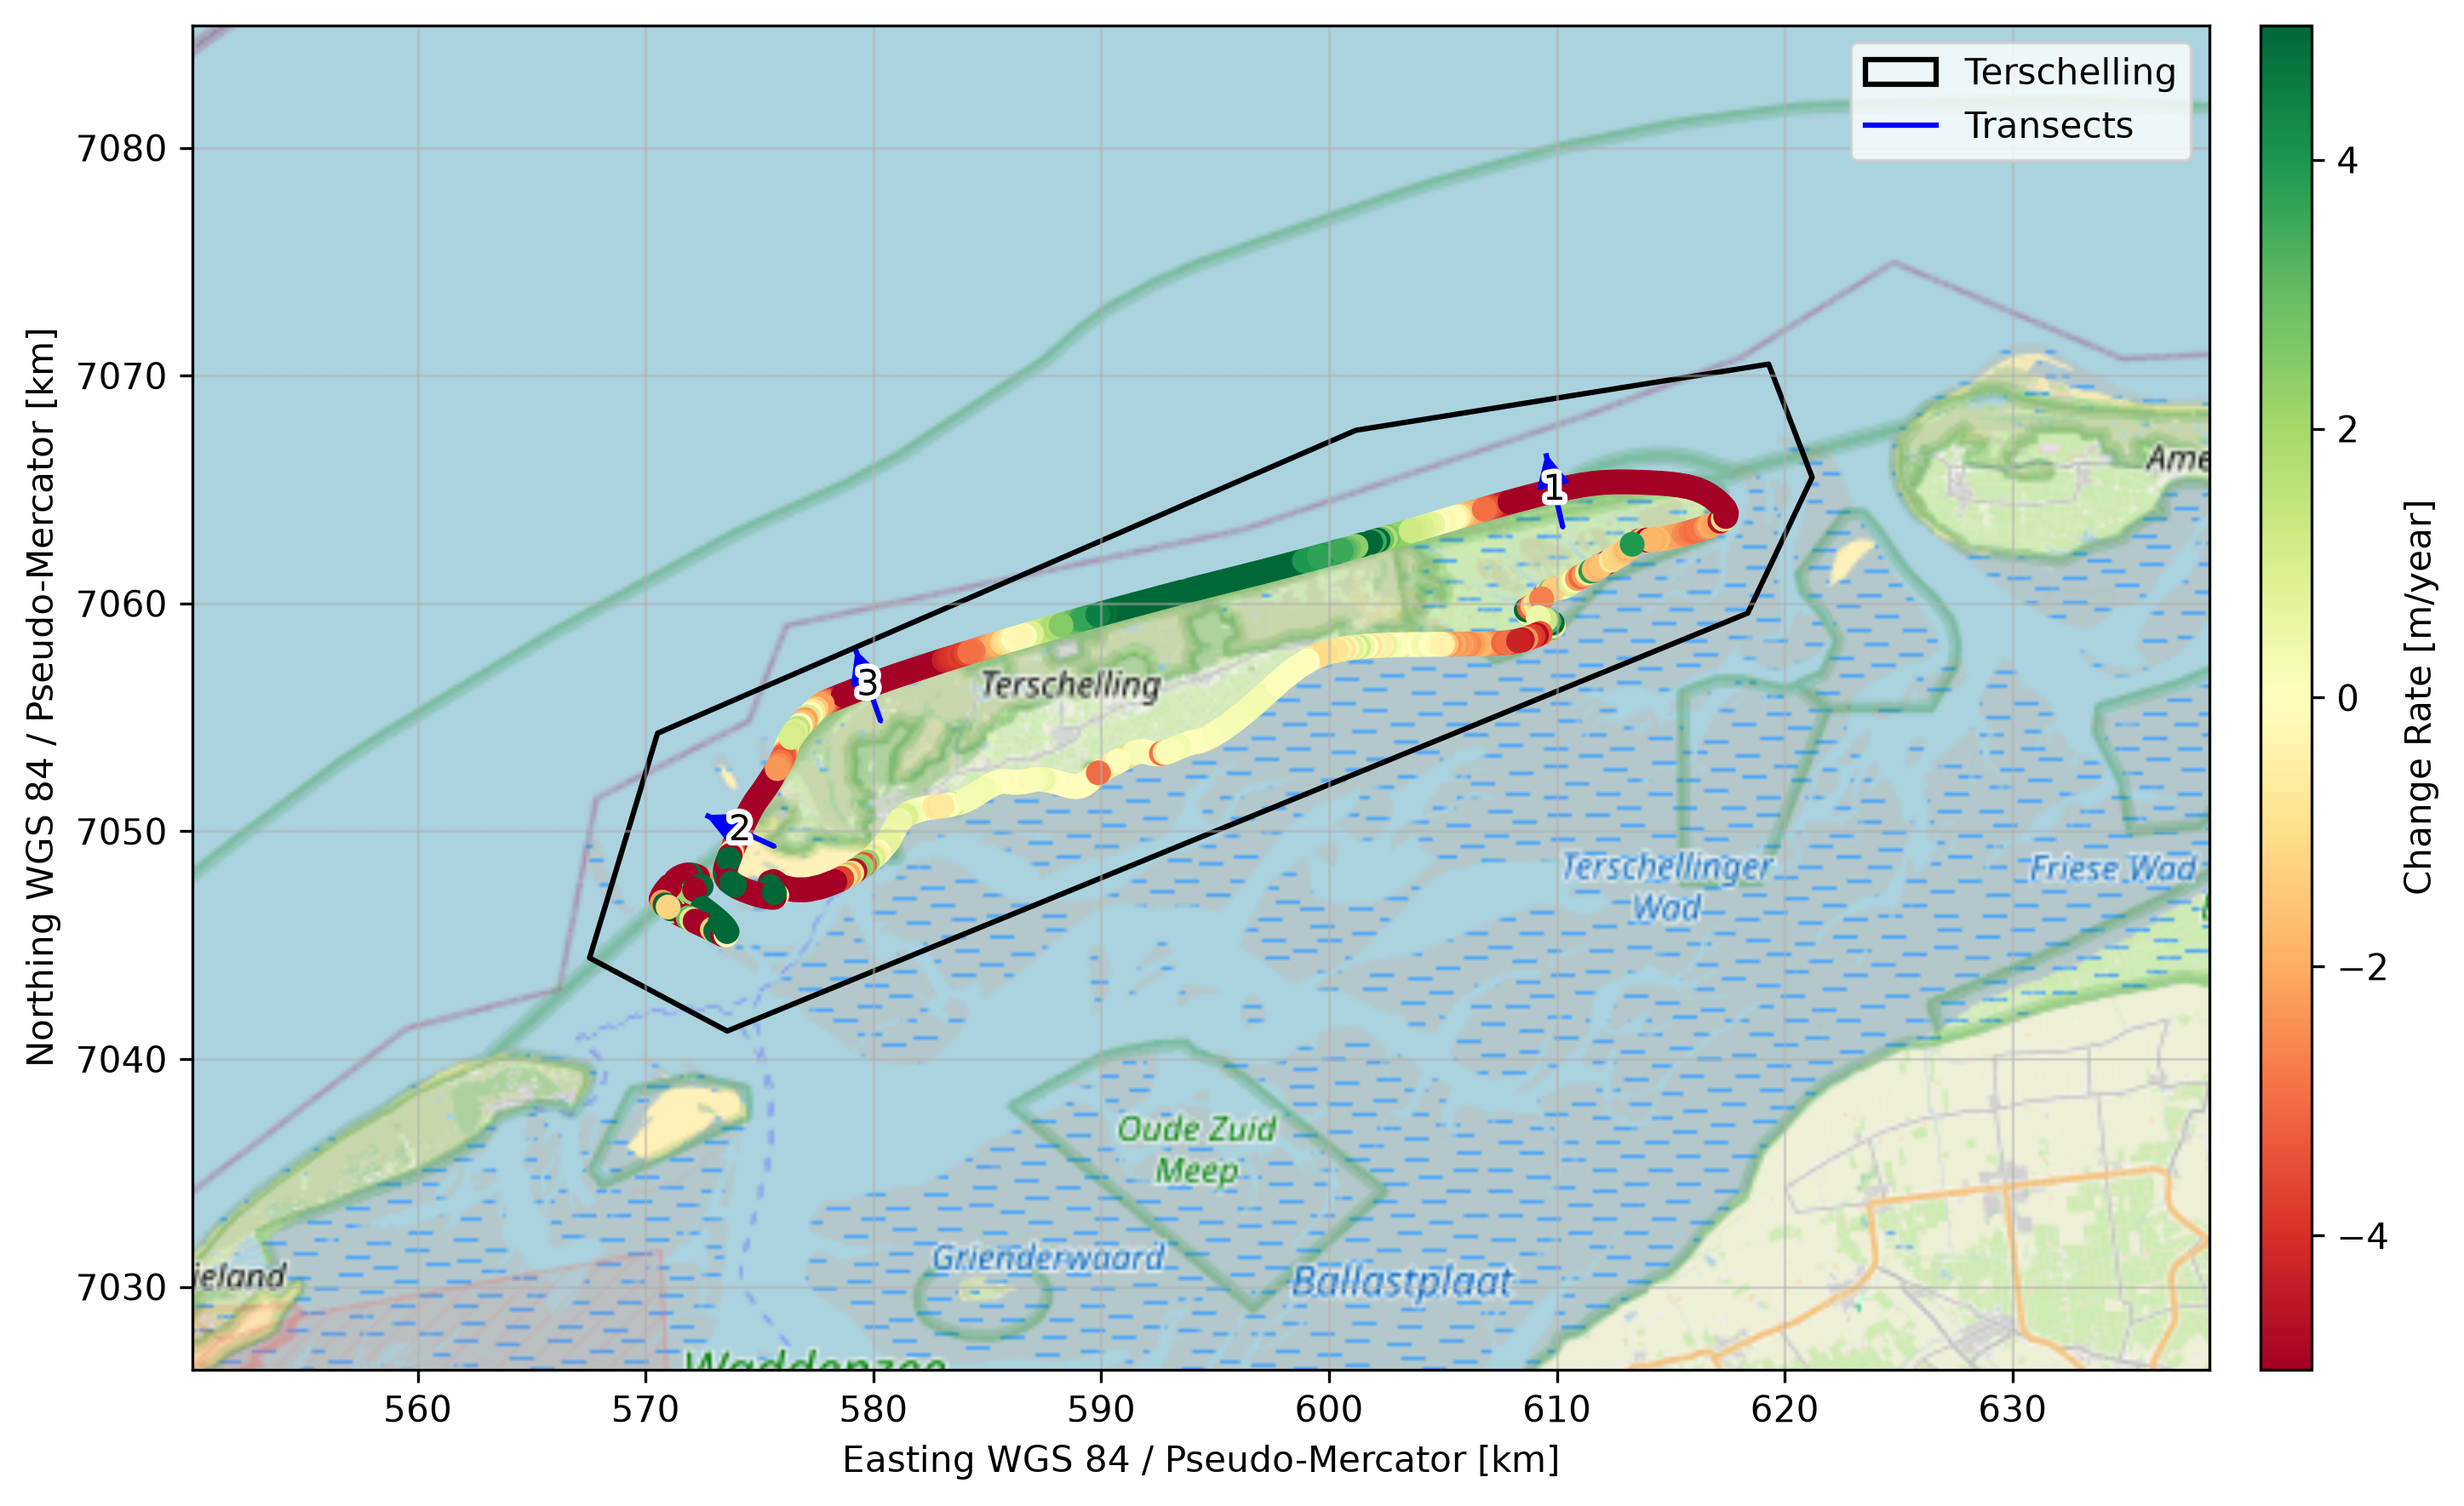
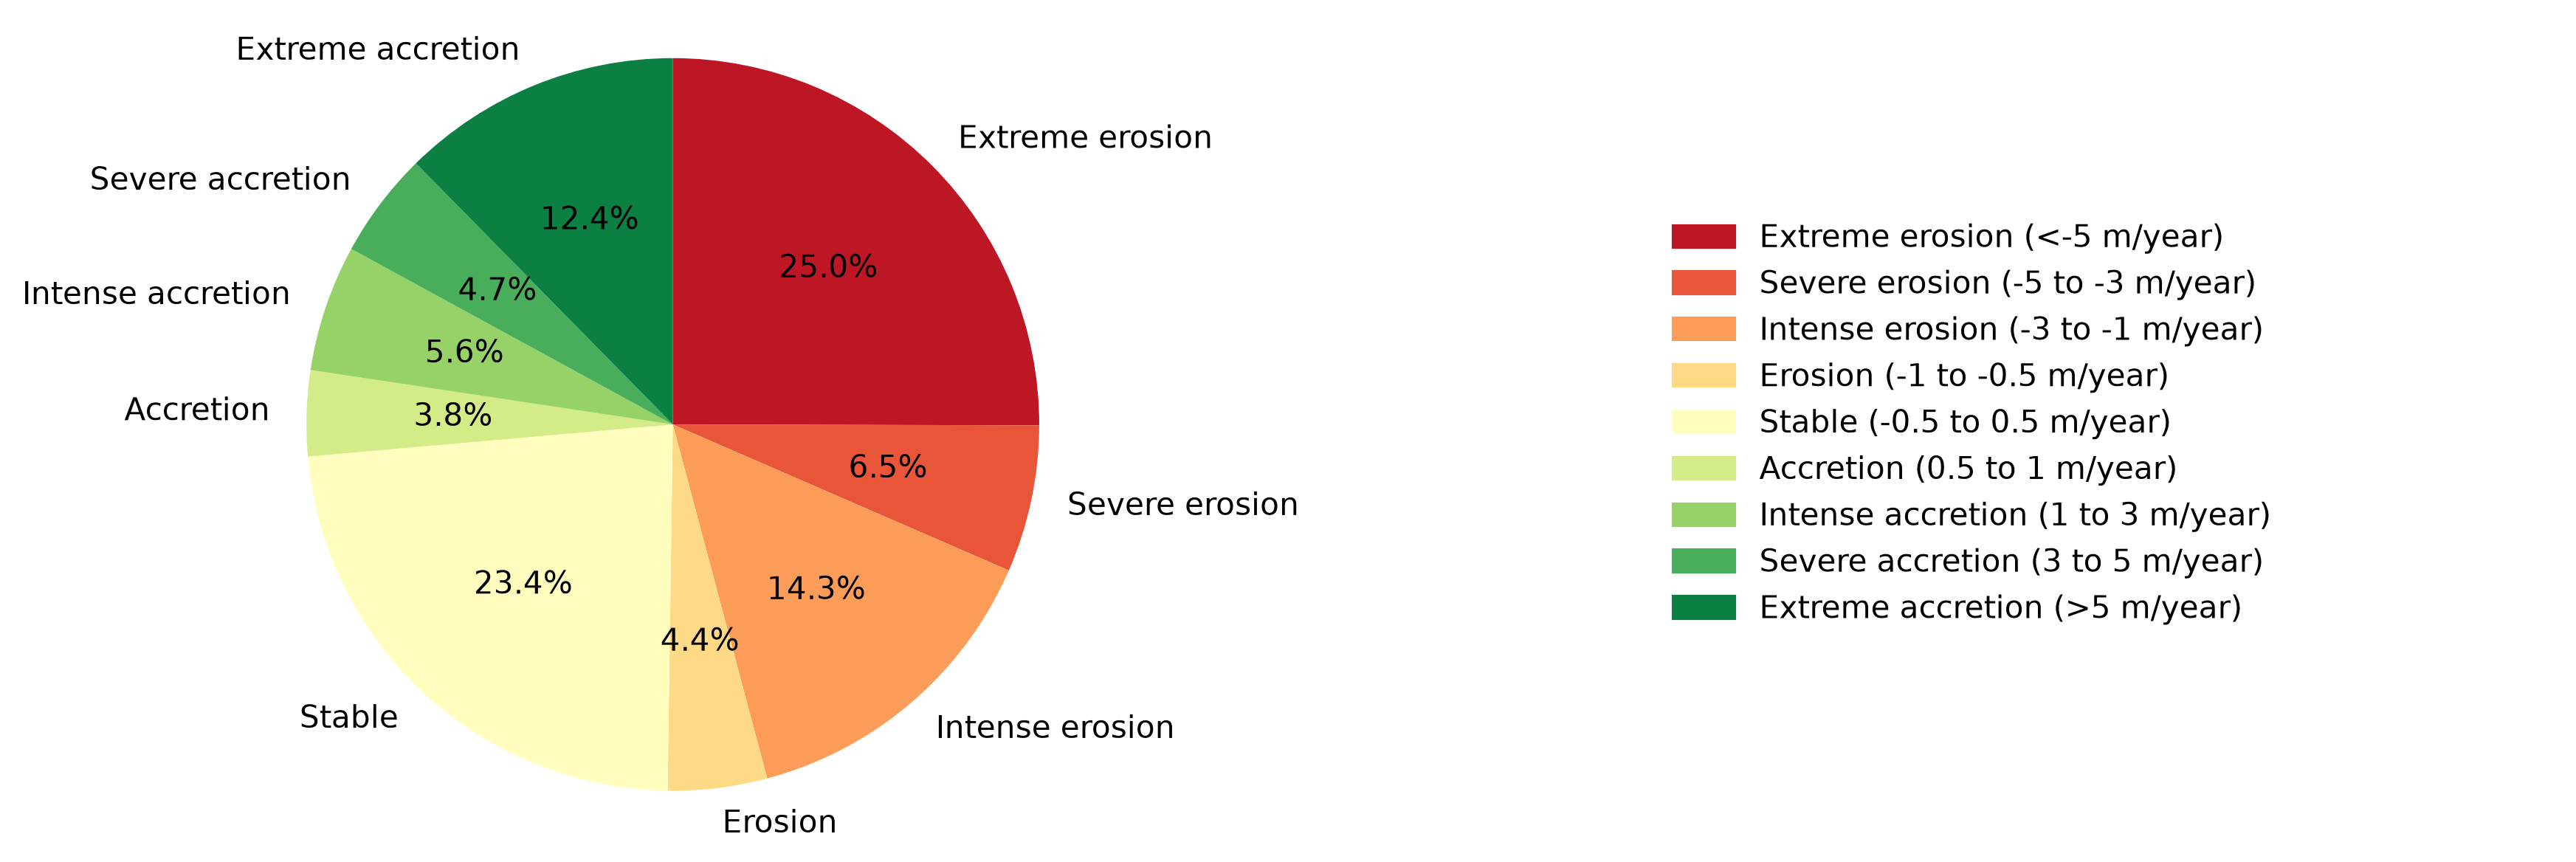
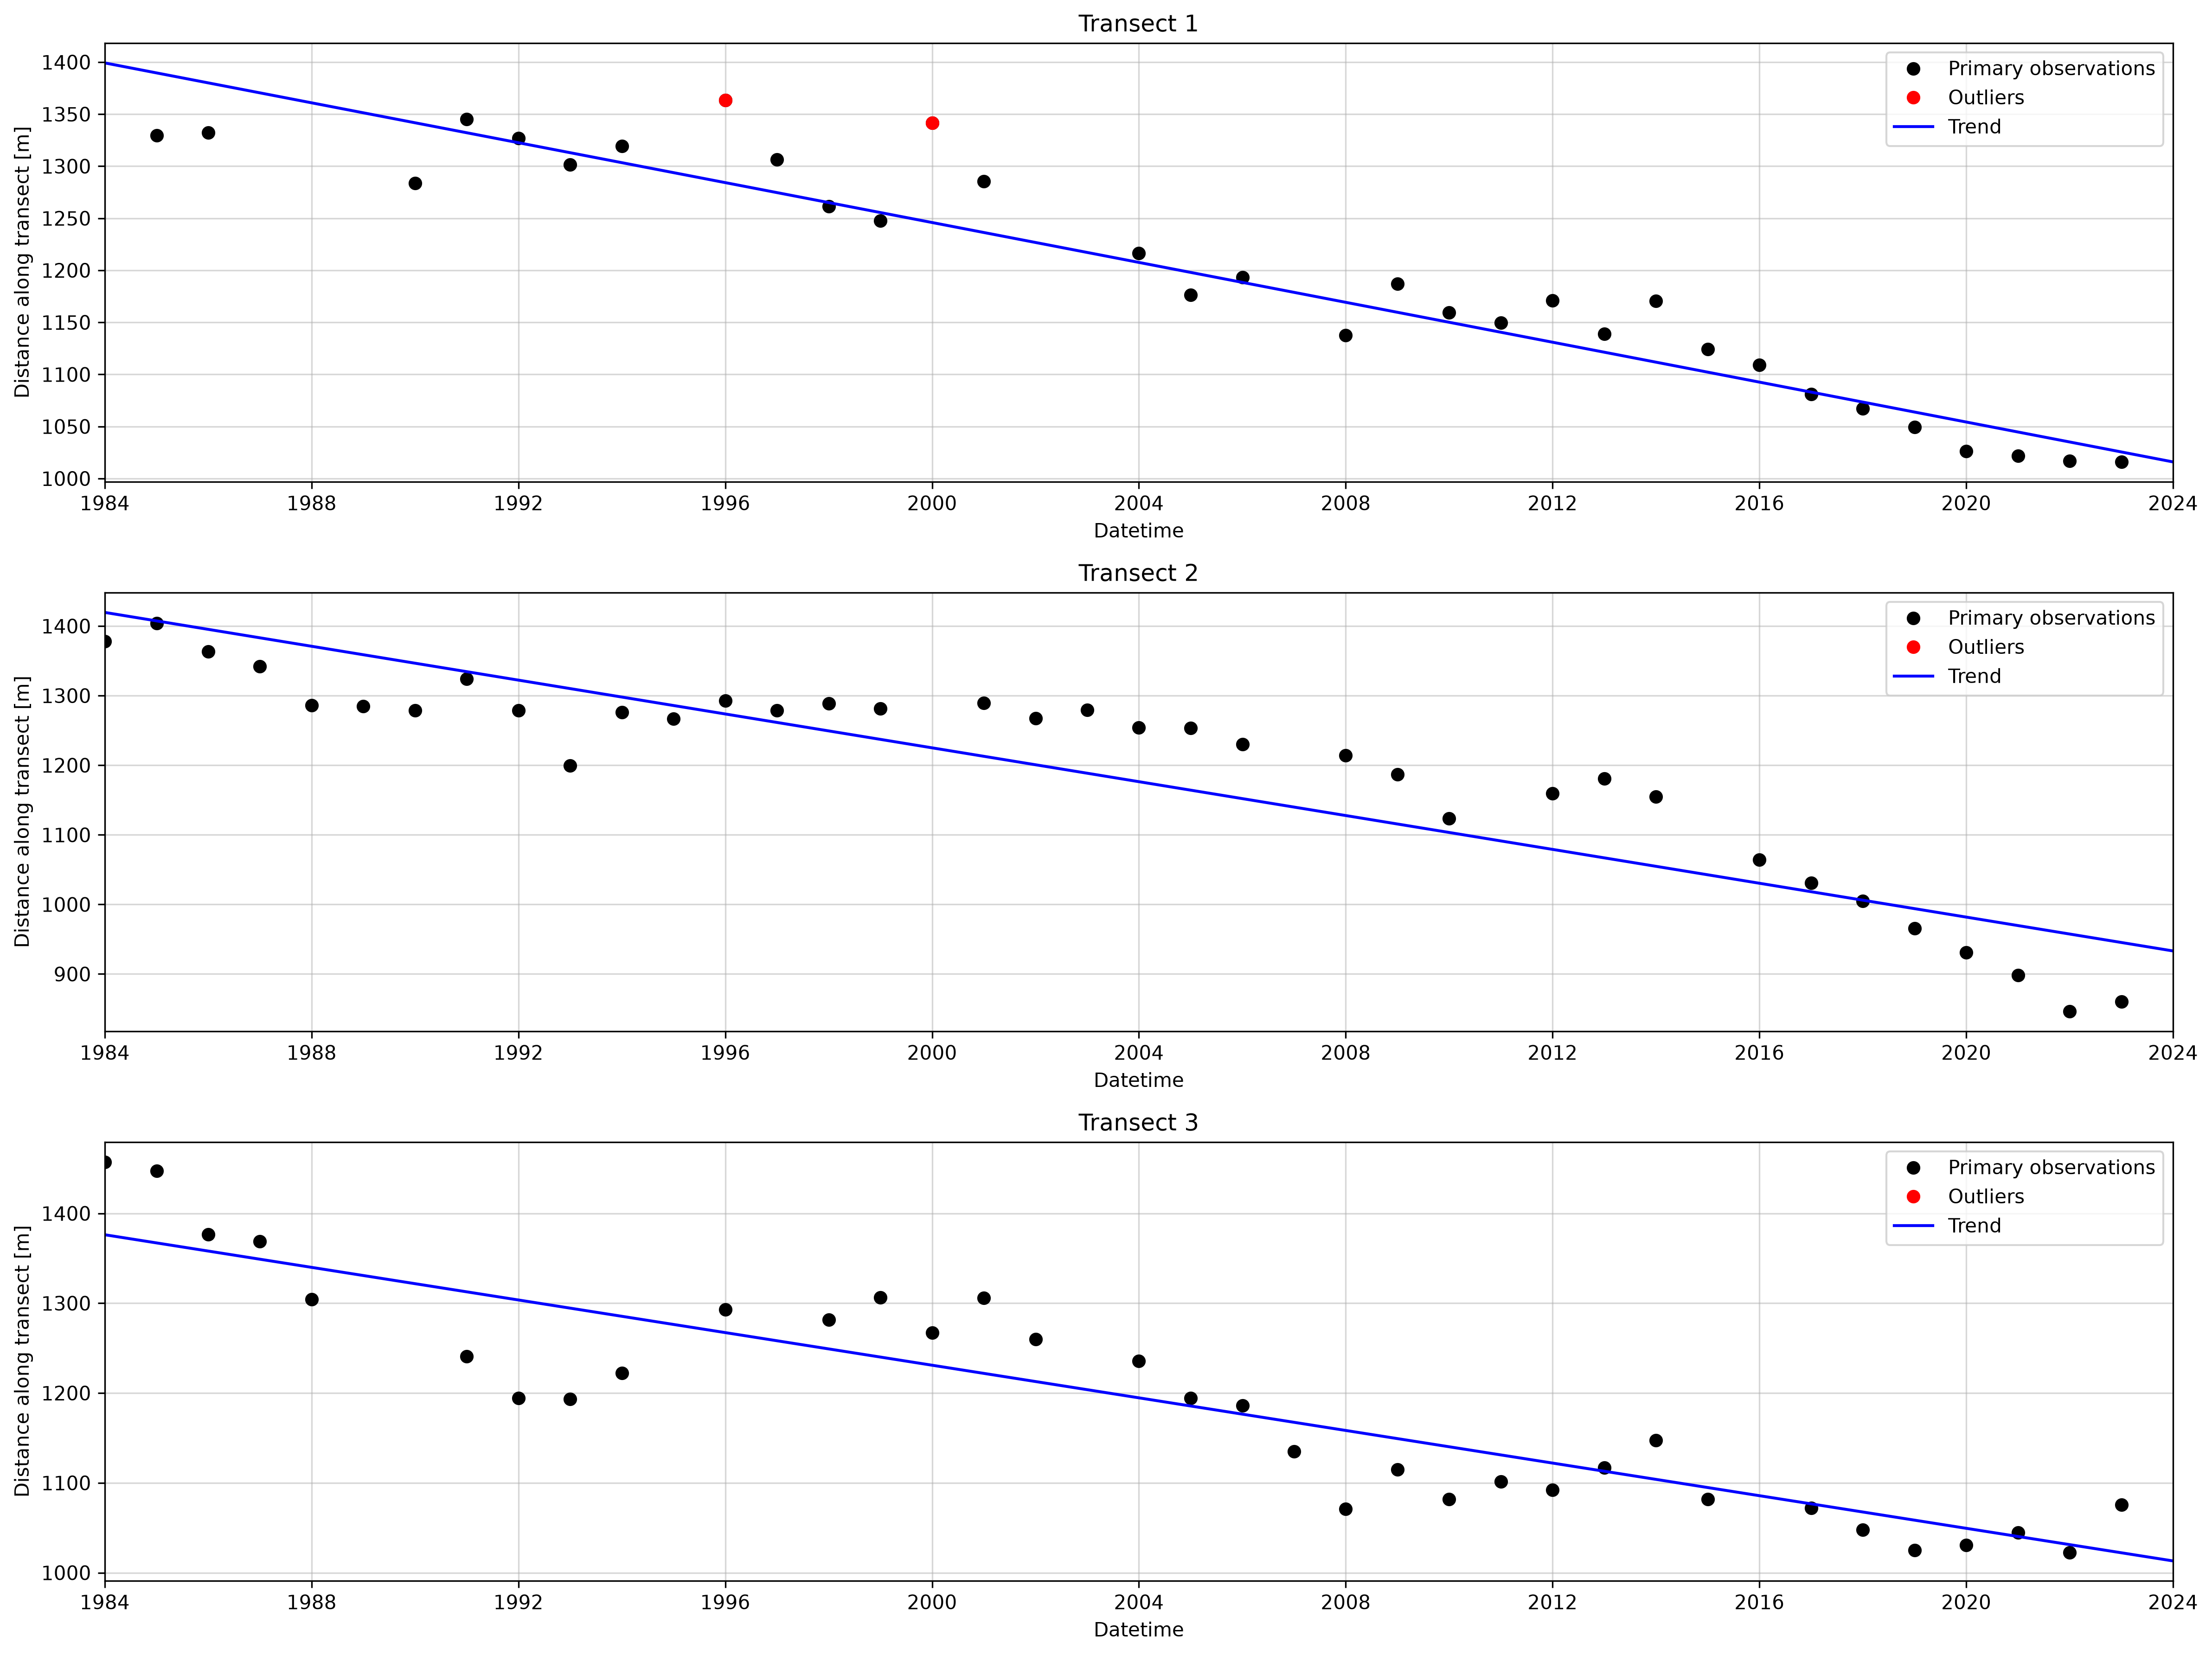

In [7]:
template = dir_path_templates / f"{template_name}.md"
figures = {
    "Figure 1": dir_path_figures / f"{template_name}_{area_name}_map.png",
    "Figure 2": dir_path_figures / f"{template_name}_{area_name}_chart.png",
    "Figure 3": dir_path_figures / f"{template_name}_{area_name}_transects.png",
}
datasets = {
    "name": area_name,
    "area of interest": gdf_areas.__geo_interface__,
    "change rate statistics": dict(zip(labels, percentages)),
    "transects": gdf_transects.__geo_interface__,
}

# Generate memo
memo = Memo(template=template, figures=figures, datasets=datasets)
memo.generate_content(rag_index_name="minikennisbank_state_of_the_coast")

# Save and display memo
memo.to_md(dir_path_memos / f"{template_name}_{area_name}_memo.md")
memo.to_html(dir_path_memos / f"{template_name}_{area_name}_memo.html")
memo.show()